In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.inspection import permutation_importance

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [9]:
df.duplicated().sum()

0

In [10]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
df["TotalCharges"].dtype

dtype('O')

In [13]:
df["TotalCharges"].head(20)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: object

In [14]:
print(df.duplicated().sum())
print(df.nunique())
print(df.describe())
print(df["TotalCharges"].dtype)
print(df["TotalCharges"].head(20))
print(df["customerID"].nunique())
print(df.shape[0])

0
customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000
object
0  

In [15]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()

11

In [16]:
temp_total = pd.to_numeric(df["TotalCharges"], errors="coerce")

df[temp_total.isna()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


Data Quality Finding — Total Charges
TotalCharges was initially stored as an object rather than a numeric variable. Investigation identified 11 blank values, all belonging to customers with zero months of tenure. These records were interpreted as newly acquired customers who had not yet accumulated charges. Rather than removing valid customers or imputing an arbitrary population statistic, the missing TotalCharges values were set to zero and the column was converted to numeric.

In [18]:
df["TotalCharges"].isna().sum()

0

In [19]:
df["TotalCharges"].dtype

dtype('O')

In [20]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df["TotalCharges"].dtype

dtype('float64')

In [21]:
df["TotalCharges"].isna().sum()

11

In [22]:
df.loc[
    (df["tenure"] == 0) & (df["TotalCharges"].isna()),
    "TotalCharges"
] = 0
df["TotalCharges"].isna().sum()

0

In [23]:
categorical_cols = df.select_dtypes(include="object").columns
categorical_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [24]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- customerID ---
customerID
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- OnlineBackup -

In [25]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [26]:
df.isnull().sum().sum()

0

In [27]:
categorical_cols = df.select_dtypes(include="object").columns.drop("customerID")

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- OnlineBackup ---
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

--- DeviceProtection ---
DeviceProtection
No                     3095
Yes                    2422
No internet service   

In [28]:
churn_rate = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
churn_rate

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

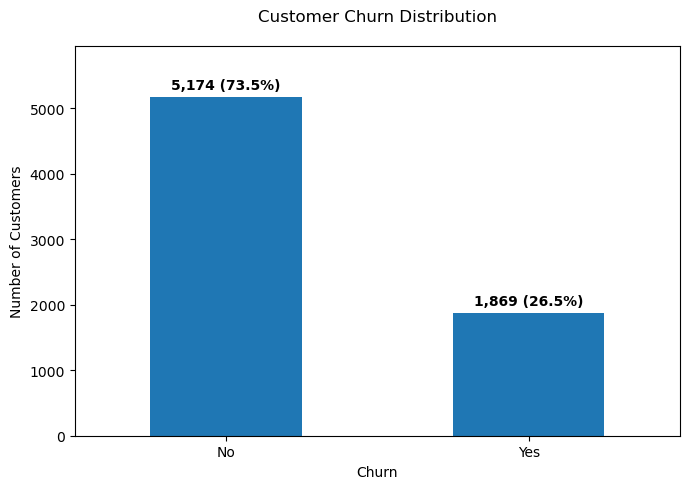

In [29]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

ax = churn_counts.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Customer Churn Distribution", pad=18)
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

# Give some extra room above the bars
plt.ylim(0, churn_counts.max() * 1.15)

for i, count in enumerate(churn_counts):
    pct = churn_pct.iloc[i]

    ax.text(
        i,
        count + 80,
        f"{count:,} ({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [30]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [31]:
df.groupby("Churn")["tenure"].median()

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64

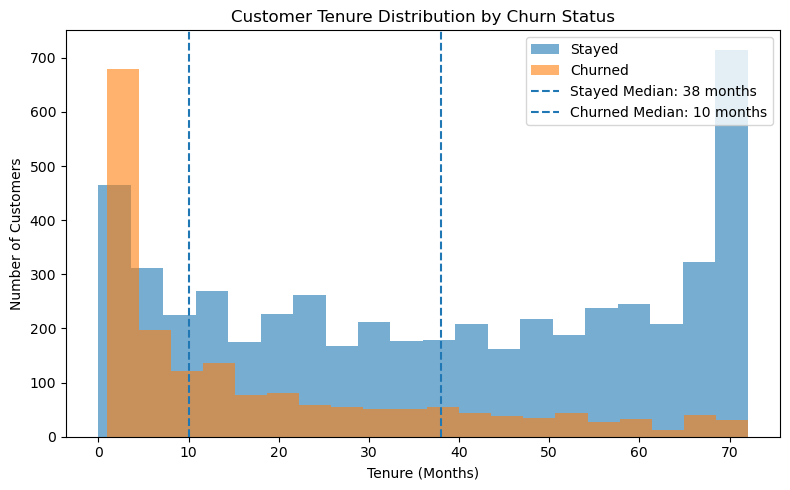

In [32]:
stayed = df[df["Churn"] == "No"]["tenure"]
churned = df[df["Churn"] == "Yes"]["tenure"]

plt.figure(figsize=(8, 5))

plt.hist(
    stayed,
    bins=20,
    alpha=0.6,
    label="Stayed"
)

plt.hist(
    churned,
    bins=20,
    alpha=0.6,
    label="Churned"
)

plt.axvline(
    stayed.median(),
    linestyle="--",
    label=f"Stayed Median: {stayed.median():.0f} months"
)

plt.axvline(
    churned.median(),
    linestyle="--",
    label=f"Churned Median: {churned.median():.0f} months"
)

plt.title("Customer Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.legend()

plt.tight_layout()
plt.show()

In [33]:
tenure_bins = [0, 12, 24, 48, 72]

tenure_labels = [
    "0-12 months",
    "13-24 months",
    "25-48 months",
    "49-72 months"
]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

In [34]:
df["TenureGroup"].value_counts().sort_index()

TenureGroup
0-12 months     2186
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64

In [35]:
tenure_churn = (
    df.groupby("TenureGroup", observed=True)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

tenure_churn

TenureGroup
0-12 months     47.44
13-24 months    28.71
25-48 months    20.39
49-72 months     9.51
Name: Churn, dtype: float64

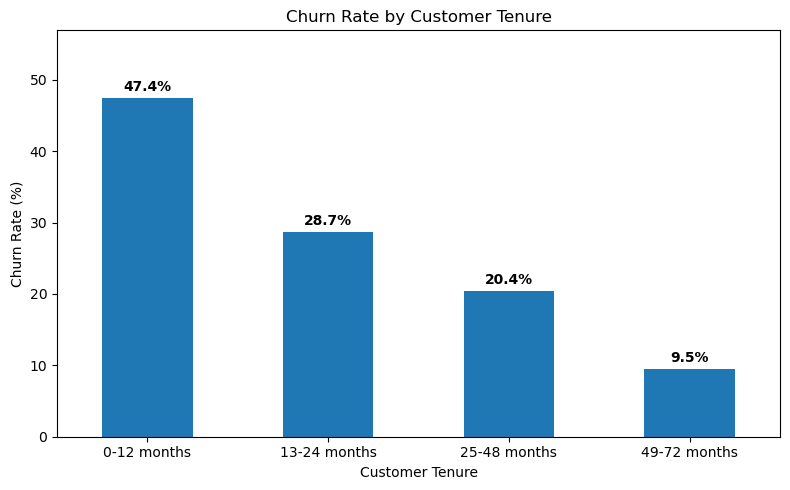

In [36]:
ax = tenure_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.ylim(0, tenure_churn.max() * 1.2)

for i, value in enumerate(tenure_churn):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [37]:
contingency_table = pd.crosstab(
    df["TenureGroup"],
    df["Churn"]
)

contingency_table

Churn,No,Yes
TenureGroup,,
0-12 months,1149,1037
13-24 months,730,294
25-48 months,1269,325
49-72 months,2026,213


In [38]:
chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 856.1002388751685
P-value: 2.9437703649803846e-185
Degrees of freedom: 3


In [39]:
n = contingency_table.to_numpy().sum()
r, k = contingency_table.shape
cramers_v = np.sqrt(
    chi2 / (n * min(r - 1, k - 1))
)
cramers_v

0.3486450189881562

In [40]:
contract_churn = (
    df.groupby("Contract")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

contract_churn

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

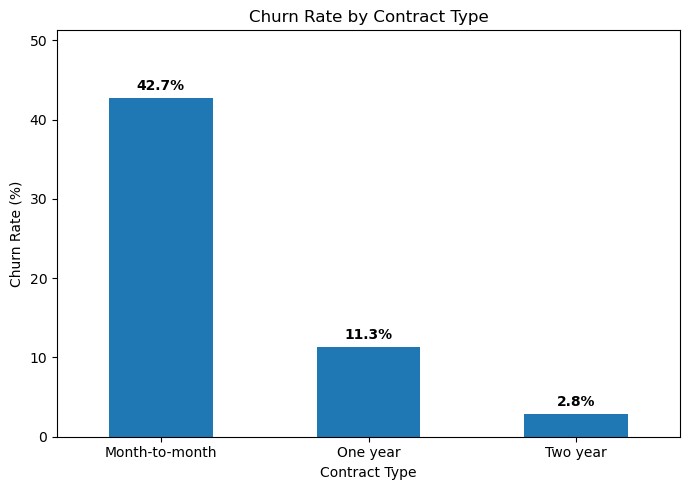

In [41]:
ax = contract_churn.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.ylim(0, contract_churn.max() * 1.2)

for i, value in enumerate(contract_churn.sort_values(ascending=False)):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [42]:
contract_table = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

contract_table

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [43]:
chi2_contract, p_contract, dof_contract, expected_contract = chi2_contingency(
    contract_table
)

print("Chi-square:", chi2_contract)
print("P-value:", p_contract)
print("Degrees of freedom:", dof_contract)

Chi-square: 1184.5965720837926
P-value: 5.863038300673391e-258
Degrees of freedom: 2


In [44]:
n = contract_table.to_numpy().sum()
r, k = contract_table.shape

cramers_v_contract = np.sqrt(
    chi2_contract / (n * min(r - 1, k - 1))
)

print("Cramer's V:", cramers_v_contract)

Cramer's V: 0.4101156965761409


In [45]:
tenure_contract = pd.crosstab(
    df["TenureGroup"],
    df["Contract"],
    normalize="index"
) * 100

tenure_contract.round(1)

Contract,Month-to-month,One year,Two year
TenureGroup,,,
0-12 months,91.2,5.7,3.1
13-24 months,72.0,19.2,8.8
25-48 months,50.3,32.5,17.2
49-72 months,15.3,28.3,56.4


In [46]:
tenure_contract_churn = (
    df.groupby(
        ["TenureGroup", "Contract"],
        observed=True
    )["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .unstack()
    .round(1)
)
tenure_contract_churn

Contract,Month-to-month,One year,Two year
TenureGroup,,,
0-12 months,51.4,10.5,0.0
13-24 months,37.7,8.1,0.0
25-48 months,32.9,10.6,2.2
49-72 months,26.0,12.9,3.3


In [47]:
tenure_contract_counts = pd.crosstab(
    df["TenureGroup"],
    df["Contract"]
)

tenure_contract_counts

Contract,Month-to-month,One year,Two year
TenureGroup,,,
0-12 months,1994,124,68
13-24 months,737,197,90
25-48 months,802,518,274
49-72 months,342,634,1263


In [48]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


In [49]:
df.groupby("Churn")["MonthlyCharges"].median()

Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64

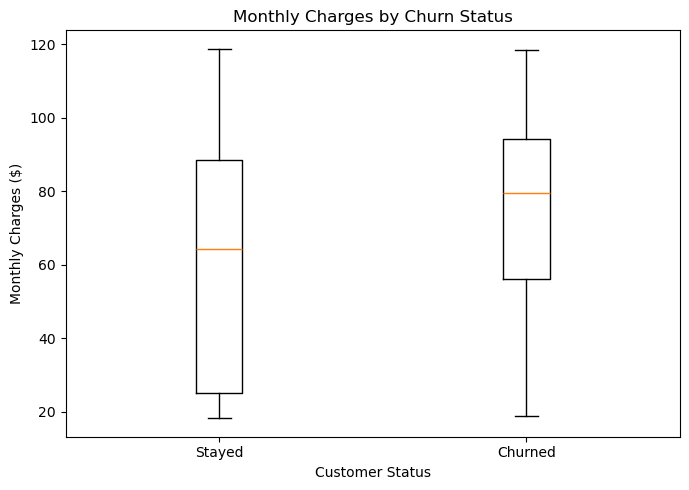

In [50]:
monthly_no = df[df["Churn"] == "No"]["MonthlyCharges"]
monthly_yes = df[df["Churn"] == "Yes"]["MonthlyCharges"]

plt.figure(figsize=(7, 5))

plt.boxplot(
    [monthly_no, monthly_yes],
    tick_labels=["Stayed", "Churned"]
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Monthly Charges ($)")

plt.tight_layout()
plt.show()

In [51]:
t_stat, p_value = ttest_ind(
    monthly_yes,
    monthly_no,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 18.407526676414673
P-value: 8.59244933154705e-73


In [52]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

internet_churn

InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64

In [53]:
internet_charges = (
    df.groupby("InternetService")["MonthlyCharges"]
      .median()
      .round(2)
)

internet_charges

InternetService
DSL            56.15
Fiber optic    91.68
No             20.15
Name: MonthlyCharges, dtype: float64

In [54]:
service_charge_churn = (
    df.groupby(
        ["InternetService", "Churn"]
    )["MonthlyCharges"]
    .median()
    .unstack()
    .round(2)
)

service_charge_churn


Churn,No,Yes
InternetService,,
DSL,59.75,49.25
Fiber optic,94.80,87.55
No,20.15,20.00


In [55]:
service_charge_mean = (
    df.groupby(
        ["InternetService", "Churn"]
    )["MonthlyCharges"]
    .mean()
    .unstack()
    .round(2)
)

service_charge_mean

Churn,No,Yes
InternetService,,
DSL,60.21,49.08
Fiber optic,93.93,88.13
No,21.14,20.37


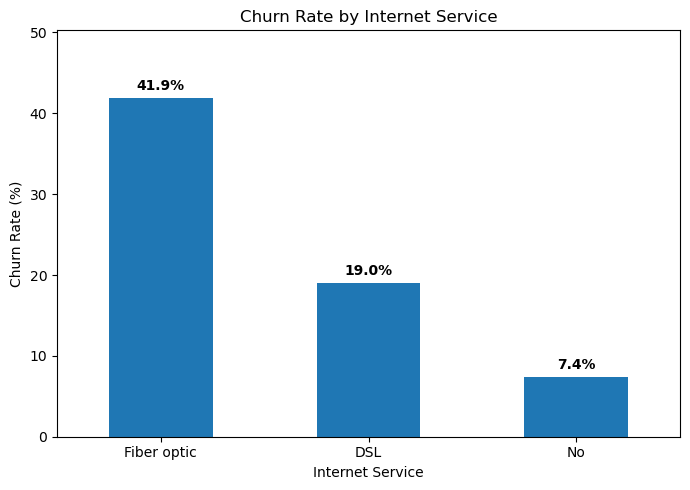

In [56]:
ax = internet_churn.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.ylim(0, internet_churn.max() * 1.2)

for i, value in enumerate(internet_churn.sort_values(ascending=False)):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [57]:
techsupport_churn = (
    df.groupby("TechSupport")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

techsupport_churn

TechSupport
No                     41.64
No internet service     7.40
Yes                    15.17
Name: Churn, dtype: float64

In [58]:
security_churn = (
    df.groupby("OnlineSecurity")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

security_churn

OnlineSecurity
No                     41.77
No internet service     7.40
Yes                    14.61
Name: Churn, dtype: float64

In [59]:
support_comparison = pd.DataFrame({
    "Tech Support": techsupport_churn,
    "Online Security": security_churn
})

support_comparison

,Tech Support,Online Security
No,41.64,41.77
No internet service,7.40,7.40
Yes,15.17,14.61


In [60]:
for col in ["gender", "SeniorCitizen", "Partner", "Dependents"]:
    
    result = (
        df.groupby(col)["Churn"]
          .apply(lambda x: (x == "Yes").mean() * 100)
          .round(2)
    )
    
    print(f"\n{col}")
    print(result)


gender
gender
Female    26.92
Male      26.16
Name: Churn, dtype: float64

SeniorCitizen
SeniorCitizen
0    23.61
1    41.68
Name: Churn, dtype: float64

Partner
Partner
No     32.96
Yes    19.66
Name: Churn, dtype: float64

Dependents
Dependents
No     31.28
Yes    15.45
Name: Churn, dtype: float64


In [61]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
      .round(2)
)

payment_churn

PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn, dtype: float64

In [62]:
X = df.drop(
    columns=[
        "Churn",
        "customerID",
        "TenureGroup"
    ]
)

y = df["Churn"]

In [63]:
X.shape

(7043, 19)

In [64]:
y.shape

(7043,)

In [65]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [67]:
print("Training set:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest set:")
print(y_test.value_counts(normalize=True) * 100)

Training set:
Churn
No     73.464679
Yes    26.535321
Name: proportion, dtype: float64

Test set:
Churn
No     73.456352
Yes    26.543648
Name: proportion, dtype: float64


In [68]:
pd.get_dummies(df)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0002-ORFBO,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_No,Churn_Yes,TenureGroup_0-12 months,TenureGroup_13-24 months,TenureGroup_25-48 months,TenureGroup_49-72 months
0,0,1,29.85,29.85,False,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
1,0,34,56.95,1889.50,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,True,False
2,0,2,53.85,108.15,False,False,False,False,False,False,...,False,False,False,True,False,True,True,False,False,False
3,0,45,42.30,1840.75,False,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
4,0,2,70.70,151.65,False,False,False,False,False,False,...,False,False,True,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,False,False,False,False,False,False,...,False,False,False,True,True,False,False,True,False,False
7039,0,72,103.20,7362.90,False,False,False,False,False,False,...,False,True,False,False,True,False,False,False,False,True
7040,0,11,29.60,346.45,False,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
7041,1,4,74.40,306.60,False,False,False,False,False,False,...,False,False,False,True,False,True,True,False,False,False


In [69]:
X_train.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [70]:
categorical_features = X_train.select_dtypes(
    include="object"
).columns.tolist()

numerical_features = X_train.select_dtypes(
    exclude="object"
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [71]:
categorical_features = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

numerical_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

binary_features = [
    'SeniorCitizen'
]

In [72]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

In [73]:
preprocessor.fit(X)

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod']),
                                ('num', StandardScaler(),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('binary', 'passthrough', ['SeniorCitizen'])])

In [74]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [75]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [76]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('binary', 'passthrough',
                                                  ['SeniorCitizen'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [77]:
y_pred = logistic_model.predict(X_test)

In [78]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8055358410220014

Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



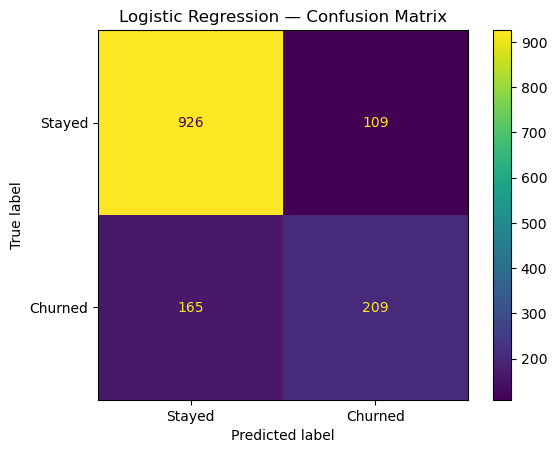

In [79]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["No", "Yes"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot()

plt.title("Logistic Regression — Confusion Matrix")
plt.show()

In [80]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8419566509080574


In [81]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

In [82]:
decision_tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('binary', 'passthrough',
                                                  ['SeniorCitizen'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [83]:
y_pred_dt = decision_tree_model.predict(X_test)

In [84]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_dt)
)

Accuracy: 0.7246273953158269

Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.81      0.81      1035
         Yes       0.48      0.49      0.49       374

    accuracy                           0.72      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.72      0.73      1409

ROC-AUC: 0.6509468082358107


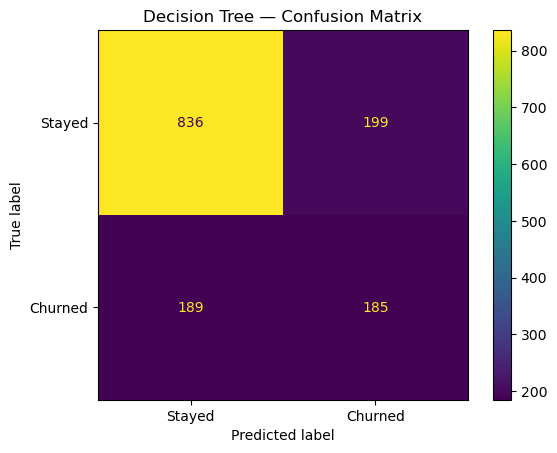

In [85]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt,
    labels=["No", "Yes"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Stayed", "Churned"]
)

disp.plot()

plt.title("Decision Tree — Confusion Matrix")
plt.show()

In [86]:
DecisionTreeClassifier(random_state=42)

DecisionTreeClassifier(random_state=42)

In [87]:
train_accuracy_dt = decision_tree_model.score(
    X_train,
    y_train
)

test_accuracy_dt = decision_tree_model.score(
    X_test,
    y_test
)

print("Training Accuracy:", train_accuracy_dt)
print("Test Accuracy:", test_accuracy_dt)

Training Accuracy: 0.9980475683351083
Test Accuracy: 0.7246273953158269


In [88]:


depths = [3, 4, 5, 6, 8, 10]

for depth in depths:
    
    dt_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                DecisionTreeClassifier(
                    max_depth=depth,
                    random_state=42
                )
            )
        ]
    )
    
    scores = cross_val_score(
        dt_model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc"
    )
    
    print(
        f"Depth {depth}: "
        f"Mean ROC-AUC = {scores.mean():.3f}"
    )

Depth 3: Mean ROC-AUC = 0.819
Depth 4: Mean ROC-AUC = 0.827
Depth 5: Mean ROC-AUC = 0.826
Depth 6: Mean ROC-AUC = 0.824
Depth 8: Mean ROC-AUC = 0.787
Depth 10: Mean ROC-AUC = 0.743


In [89]:
decision_tree_tuned = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=4,
                random_state=42
            )
        )
    ]
)

In [90]:
decision_tree_tuned.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('binary', 'passthrough',
                                                  ['SeniorCitizen'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=4, random_state=42))])

In [91]:
print(
    "Training Accuracy:",
    decision_tree_tuned.score(X_train, y_train)
)

print(
    "Test Accuracy:",
    decision_tree_tuned.score(X_test, y_test)
)

Training Accuracy: 0.7965921192758253
Test Accuracy: 0.7920511000709723


In [92]:
y_pred_dt_tuned = decision_tree_tuned.predict(X_test)

y_prob_dt_tuned = decision_tree_tuned.predict_proba(X_test)[:, 1]

In [93]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_dt_tuned)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_dt_tuned
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob_dt_tuned
    )
)

Accuracy: 0.7920511000709723

Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.91      0.87      1035
         Yes       0.66      0.45      0.54       374

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8294892660621562


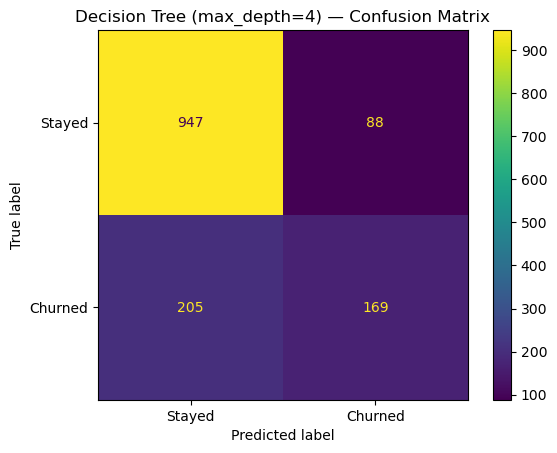

In [94]:
cm_dt_tuned = confusion_matrix(
    y_test,
    y_pred_dt_tuned,
    labels=["No", "Yes"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt_tuned,
    display_labels=["Stayed", "Churned"]
)

disp.plot()

plt.title("Decision Tree (max_depth=4) — Confusion Matrix")
plt.show()

In [95]:
print(
    "Training Accuracy:",
    decision_tree_tuned.score(X_train, y_train)
)

print(
    "Test Accuracy:",
    decision_tree_tuned.score(X_test, y_test)
)

Training Accuracy: 0.7965921192758253
Test Accuracy: 0.7920511000709723


In [96]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

In [97]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('binary', 'passthrough',
                                                  ['SeniorCitizen'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [98]:
y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [99]:
print(
    "Training Accuracy:",
    random_forest_model.score(X_train, y_train)
)

print(
    "Test Accuracy:",
    random_forest_model.score(X_test, y_test)
)

print("\nClassification Report:")
print(
    classification_report(y_test, y_pred_rf)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_rf)
)

Training Accuracy: 0.9980475683351083
Test Accuracy: 0.7814052519517388

Classification Report:
              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1035
         Yes       0.61      0.49      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409

ROC-AUC: 0.8202588545299543


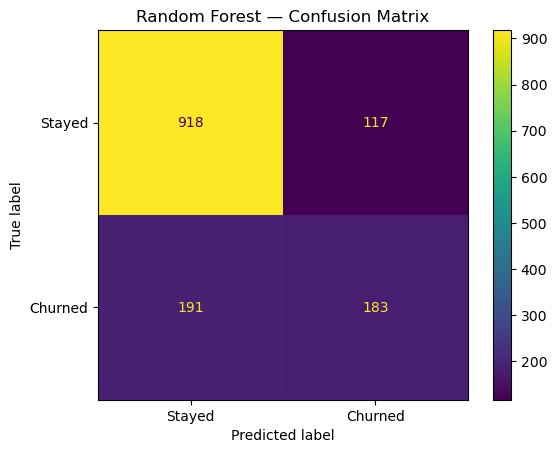

In [100]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["No", "Yes"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Stayed", "Churned"]
)

disp.plot()

plt.title("Random Forest — Confusion Matrix")
plt.show()

In [101]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

param_grid = {
    "classifier__max_depth": [4, 6, 8, 10],
    "classifier__min_samples_leaf": [1, 5, 10]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['gender',
                                                                          'Partner',
                                                                          'Dependents',
                                                                          'PhoneService',
                                                                          'MultipleLines',
                                                                          'InternetService',
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges']),
                                                                        ('binary',
                                                                         'passthrough',
                                                                         ['SeniorCitizen'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [4, 6, 8, 10],
                         'classifier__min_samples_leaf': [1, 5, 10]},
             scoring='roc_auc')

In [102]:
print("Best parameters:")
print(rf_grid.best_params_)

print(
    "Best CV ROC-AUC:",
    rf_grid.best_score_
)

Best parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 10}
Best CV ROC-AUC: 0.8481051126948798


In [103]:
("classifier", RandomForestClassifier(...))

('classifier', RandomForestClassifier(n_estimators=Ellipsis))

In [104]:
best_rf_model = rf_grid.best_estimator_

In [105]:
print(
    "Training Accuracy:",
    best_rf_model.score(X_train, y_train)
)

print(
    "Test Accuracy:",
    best_rf_model.score(X_test, y_test)
)

Training Accuracy: 0.8313809016684416
Test Accuracy: 0.8055358410220014


In [106]:
y_pred_rf_tuned = best_rf_model.predict(X_test)

y_prob_rf_tuned = best_rf_model.predict_proba(X_test)[:, 1]

In [107]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_rf_tuned)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf_tuned
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob_rf_tuned
    )
)

Accuracy: 0.8055358410220014

Classification Report:
              precision    recall  f1-score   support

          No       0.84      0.91      0.87      1035
         Yes       0.68      0.51      0.58       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8440698545557881


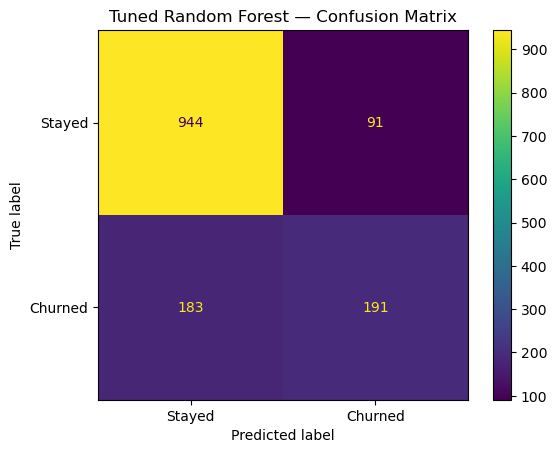

In [108]:
cm_rf_tuned = confusion_matrix(
    y_test,
    y_pred_rf_tuned,
    labels=["No", "Yes"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_tuned,
    display_labels=["Stayed", "Churned"]
)

disp.plot()

plt.title("Tuned Random Forest — Confusion Matrix")
plt.show()

In [109]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [110]:
y_train_nn = y_train.map({"No": 0, "Yes": 1})
y_test_nn = y_test.map({"No": 0, "Yes": 1})

In [111]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(5634, 45)
(1409, 45)


In [112]:
ann_model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_processed.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

C:\Users\shrey\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [113]:
ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [114]:
history = ann_model.fit(
    X_train_processed,
    y_train_nn,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7324 - loss: 0.5165 - val_accuracy: 0.7728 - val_loss: 0.4515
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8065 - loss: 0.4183 - val_accuracy: 0.7986 - val_loss: 0.4420
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8101 - loss: 0.4121 - val_accuracy: 0.7879 - val_loss: 0.4403
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8096 - loss: 0.4085 - val_accuracy: 0.7941 - val_loss: 0.4367
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8079 - loss: 0.4074 - val_accuracy: 0.7879 - val_loss: 0.4374
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8107 - loss: 0.4053 - val_accuracy: 0.7977 - val_loss: 0.4347
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8110 - loss: 0.4034 - val_accuracy: 0.8012 - val_loss: 0.4360
Epoch 8/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8116 - loss: 0.4022 - val_accuracy: 0

In [115]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [116]:
ann_model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_processed.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [117]:
history = ann_model.fit(
    X_train_processed,
    y_train_nn,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7085 - loss: 0.5339 - val_accuracy: 0.7897 - val_loss: 0.4448
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8043 - loss: 0.4186 - val_accuracy: 0.7888 - val_loss: 0.4422
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8065 - loss: 0.4116 - val_accuracy: 0.7906 - val_loss: 0.4387
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8072 - loss: 0.4084 - val_accuracy: 0.7941 - val_loss: 0.4377
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8105 - loss: 0.4050 - val_accuracy: 0.7950 - val_loss: 0.4406
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8116 - loss: 0.4037 - val_accuracy: 0.7933 - val_loss: 0.4399
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8125 - loss: 0.4020 - val_accuracy: 0.7950 - val_loss: 0.4378


In [118]:
restore_best_weights=True

In [119]:
y_prob_ann = ann_model.predict(X_test_processed).ravel()

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [120]:
y_pred_ann = (y_prob_ann >= 0.5).astype(int)

In [121]:
print(
    "Accuracy:",
    accuracy_score(y_test_nn, y_pred_ann)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_nn,
        y_pred_ann,
        target_names=["No", "Yes"]
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test_nn,
        y_prob_ann
    )
)

Accuracy: 0.8034066713981547

Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409

ROC-AUC: 0.8409103825983623


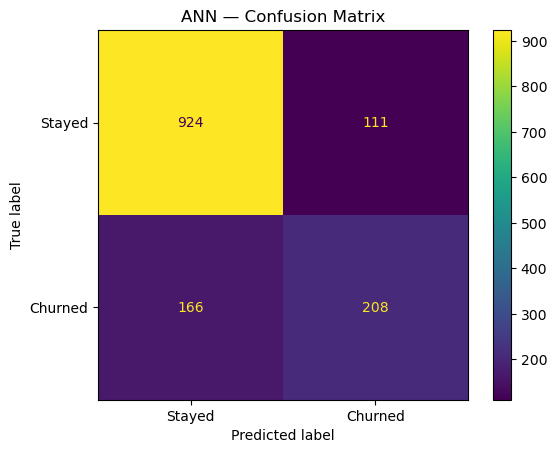

In [122]:
cm_ann = confusion_matrix(
    y_test_nn,
    y_pred_ann
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ann,
    display_labels=["Stayed", "Churned"]
)

disp.plot()

plt.title("ANN — Confusion Matrix")
plt.show()

In [123]:
feature_names = (
    logistic_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print("Number of transformed features:", len(feature_names))

feature_names

Number of transformed features: 45


array(['cat__gender_Female', 'cat__gender_Male', 'cat__Partner_No',
       'cat__Partner_Yes', 'cat__Dependents_No', 'cat__Dependents_Yes',
       'cat__PhoneService_No', 'cat__PhoneService_Yes',
       'cat__MultipleLines_No', 'cat__MultipleLines_No phone service',
       'cat__MultipleLines_Yes', 'cat__InternetService_DSL',
       'cat__InternetService_Fiber optic', 'cat__InternetService_No',
       'cat__OnlineSecurity_No',
       'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No',
       'cat__OnlineBackup_No internet service', 'cat__OnlineBackup_Yes',
       'cat__DeviceProtection_No',
       'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes', 'cat__TechSupport_No',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes',
       'cat__StreamingTV_No', 'cat__StreamingTV_No internet service',
       'cat__StreamingTV_Yes', 'cat__StreamingMovies_No',
       'cat__StreamingMovies_No internet se

In [124]:
logistic_model.named_steps["classifier"]

LogisticRegression(max_iter=1000)

In [125]:
coefficients = (
    logistic_model
    .named_steps["classifier"]
    .coef_[0]
)

print("Number of coefficients:", len(coefficients))

Number of coefficients: 45


In [126]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df.head()

,Feature,Coefficient
0,cat__gender_Female,-0.168806
1,cat__gender_Male,-0.147044
2,cat__Partner_No,-0.168828
3,cat__Partner_Yes,-0.147022
4,cat__Dependents_No,-0.045281


In [127]:
coef_df = coef_df.sort_values(
    "Coefficient",
    ascending=False
)

coef_df.head(10)

,Feature,Coefficient
12,cat__InternetService_Fiber optic,0.651066
32,cat__Contract_Month-to-month,0.576117
43,num__TotalCharges,0.525363
28,cat__StreamingTV_Yes,0.208361
31,cat__StreamingMovies_Yes,0.208304
39,cat__PaymentMethod_Electronic check,0.197795
14,cat__OnlineSecurity_No,0.156808
44,binary__SeniorCitizen,0.144545
23,cat__TechSupport_No,0.131505
10,cat__MultipleLines_Yes,0.109912


In [128]:
coef_df.tail(10)

,Feature,Coefficient
24,cat__TechSupport_No internet service,-0.306057
21,cat__DeviceProtection_No internet service,-0.306057
18,cat__OnlineBackup_No internet service,-0.306057
15,cat__OnlineSecurity_No internet service,-0.306057
13,cat__InternetService_No,-0.306057
35,cat__PaperlessBilling_No,-0.343703
42,num__MonthlyCharges,-0.620723
11,cat__InternetService_DSL,-0.660859
34,cat__Contract_Two year,-0.770715
41,num__tenure,-1.249501


In [129]:
perm_importance = permutation_importance(
    logistic_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)

In [130]:
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df

,Feature,Importance
4,tenure,0.169129
7,InternetService,0.039371
17,MonthlyCharges,0.034065
14,Contract,0.033841
18,TotalCharges,0.013841
8,OnlineSecurity,0.004080
13,StreamingMovies,0.003818
12,StreamingTV,0.003526
11,TechSupport,0.003513
16,PaymentMethod,0.003027


In [131]:
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(max_iter=1000)
        )
    ]
)

In [132]:
final_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('binary', 'passthrough',
                                                  ['SeniorCitizen'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [133]:
churn_probability = final_model.predict_proba(X)[:, 1]

In [134]:
customer_risk = df[[
    "customerID",
    "tenure",
    "Contract",
    "InternetService",
    "MonthlyCharges",
    "TotalCharges",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity",
    "Churn"
]].copy()

In [135]:
customer_risk["ChurnProbability"] = churn_probability

In [136]:
customer_risk["ChurnProbabilityPct"] = (
    customer_risk["ChurnProbability"] * 100
).round(1)

In [137]:
customer_risk.sort_values(
    "ChurnProbability",
    ascending=False
).head(10)

,customerID,tenure,Contract,InternetService,MonthlyCharges,TotalCharges,PaymentMethod,TechSupport,OnlineSecurity,Churn,ChurnProbability,ChurnProbabilityPct
3380,5178-LMXOP,1,Month-to-month,Fiber optic,95.10,95.10,Electronic check,No,No,Yes,0.845542,84.6
4800,9300-AGZNL,1,Month-to-month,Fiber optic,94.00,94.00,Electronic check,No,No,Yes,0.844920,84.5
1976,9497-QCMMS,1,Month-to-month,Fiber optic,93.55,93.55,Electronic check,No,No,Yes,0.844547,84.5
1410,7024-OHCCK,2,Month-to-month,Fiber optic,93.85,170.85,Electronic check,No,No,Yes,0.843370,84.3
2208,7216-EWTRS,1,Month-to-month,Fiber optic,100.80,100.80,Electronic check,No,No,Yes,0.842584,84.3
3749,4424-TKOPW,2,Month-to-month,Fiber optic,93.85,196.75,Electronic check,No,No,Yes,0.841239,84.1
6368,2720-WGKHP,2,Month-to-month,Fiber optic,94.00,181.70,Electronic check,No,No,Yes,0.840750,84.1
3159,5150-ITWWB,3,Month-to-month,Fiber optic,94.85,335.75,Electronic check,No,No,No,0.839908,84.0
997,1374-DMZUI,4,Month-to-month,Fiber optic,94.30,424.45,Electronic check,No,No,Yes,0.838478,83.8
301,8098-LLAZX,4,Month-to-month,Fiber optic,95.45,396.10,Electronic check,No,No,Yes,0.838251,83.8


In [138]:
customer_risk["ChurnProbabilityPct"].describe()

count    7043.000000
mean       26.540125
std        24.293622
min         0.100000
25%         4.400000
50%        19.400000
75%        46.050000
max        84.600000
Name: ChurnProbabilityPct, dtype: float64

In [139]:
customer_risk.sort_values(
    "ChurnProbability",
    ascending=False
).head(10)

,customerID,tenure,Contract,InternetService,MonthlyCharges,TotalCharges,PaymentMethod,TechSupport,OnlineSecurity,Churn,ChurnProbability,ChurnProbabilityPct
3380,5178-LMXOP,1,Month-to-month,Fiber optic,95.10,95.10,Electronic check,No,No,Yes,0.845542,84.6
4800,9300-AGZNL,1,Month-to-month,Fiber optic,94.00,94.00,Electronic check,No,No,Yes,0.844920,84.5
1976,9497-QCMMS,1,Month-to-month,Fiber optic,93.55,93.55,Electronic check,No,No,Yes,0.844547,84.5
1410,7024-OHCCK,2,Month-to-month,Fiber optic,93.85,170.85,Electronic check,No,No,Yes,0.843370,84.3
2208,7216-EWTRS,1,Month-to-month,Fiber optic,100.80,100.80,Electronic check,No,No,Yes,0.842584,84.3
3749,4424-TKOPW,2,Month-to-month,Fiber optic,93.85,196.75,Electronic check,No,No,Yes,0.841239,84.1
6368,2720-WGKHP,2,Month-to-month,Fiber optic,94.00,181.70,Electronic check,No,No,Yes,0.840750,84.1
3159,5150-ITWWB,3,Month-to-month,Fiber optic,94.85,335.75,Electronic check,No,No,No,0.839908,84.0
997,1374-DMZUI,4,Month-to-month,Fiber optic,94.30,424.45,Electronic check,No,No,Yes,0.838478,83.8
301,8098-LLAZX,4,Month-to-month,Fiber optic,95.45,396.10,Electronic check,No,No,Yes,0.838251,83.8


In [140]:
def assign_risk(prob):
    if prob >= 0.50:
        return "High"
    elif prob >= 0.30:
        return "Medium"
    else:
        return "Low"

customer_risk["RiskLevel"] = (
    customer_risk["ChurnProbability"]
    .apply(assign_risk)
)

In [141]:
customer_risk["RiskLevel"].value_counts()

RiskLevel
Low       4385
High      1568
Medium    1090
Name: count, dtype: int64

In [142]:
customer_risk["RiskLevel"].value_counts(normalize=True) * 100

RiskLevel
Low       62.26040
High      22.26324
Medium    15.47636
Name: proportion, dtype: float64

In [143]:
risk_validation = (
    customer_risk
    .groupby("RiskLevel", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(1)
)

risk_validation

RiskLevel
High      66.2
Low        9.7
Medium    37.2
Name: Churn, dtype: float64

In [144]:
def recommend_action(row):

    actions = []

    if row["RiskLevel"] == "High":
        actions.append("Priority retention outreach")

    if row["Contract"] == "Month-to-month":
        actions.append("Review longer-term contract incentive")

    if row["TechSupport"] == "No":
        actions.append("Review Tech Support offer")

    if row["OnlineSecurity"] == "No":
        actions.append("Review Online Security offer")

    if row["PaymentMethod"] == "Electronic check":
        actions.append("Review automatic payment incentive")

    if len(actions) == 0:
        actions.append("Standard customer engagement")

    return " | ".join(actions)

In [145]:
customer_risk["RecommendedAction"] = (
    customer_risk.apply(
        recommend_action,
        axis=1
    )
)

In [146]:
customer_risk[
    [
        "customerID",
        "ChurnProbabilityPct",
        "RiskLevel",
        "RecommendedAction"
    ]
].sort_values(
    "ChurnProbabilityPct",
    ascending=False
).head(10)

,customerID,ChurnProbabilityPct,RiskLevel,RecommendedAction
3380,5178-LMXOP,84.6,High,Priority retention outreach | Review longer-te...
1976,9497-QCMMS,84.5,High,Priority retention outreach | Review longer-te...
4800,9300-AGZNL,84.5,High,Priority retention outreach | Review longer-te...
2208,7216-EWTRS,84.3,High,Priority retention outreach | Review longer-te...
1410,7024-OHCCK,84.3,High,Priority retention outreach | Review longer-te...
6368,2720-WGKHP,84.1,High,Priority retention outreach | Review longer-te...
3749,4424-TKOPW,84.1,High,Priority retention outreach | Review longer-te...
3159,5150-ITWWB,84.0,High,Priority retention outreach | Review longer-te...
301,8098-LLAZX,83.8,High,Priority retention outreach | Review longer-te...
997,1374-DMZUI,83.8,High,Priority retention outreach | Review longer-te...


In [147]:
print(
    customer_risk
    .sort_values("ChurnProbabilityPct", ascending=False)
    .iloc[0]["RecommendedAction"]
)

Priority retention outreach | Review longer-term contract incentive | Review Tech Support offer | Review Online Security offer | Review automatic payment incentive


In [148]:
customer_risk.to_csv(
    "customer_intelligence_output.csv",
    index=False
)

In [149]:
customer_risk.shape

(7043, 14)

In [150]:
customer_risk.columns

Index(['customerID', 'tenure', 'Contract', 'InternetService', 'MonthlyCharges',
       'TotalCharges', 'PaymentMethod', 'TechSupport', 'OnlineSecurity',
       'Churn', 'ChurnProbability', 'ChurnProbabilityPct', 'RiskLevel',
       'RecommendedAction'],
      dtype='object')

In [151]:
customer_risk.columns.tolist()

['customerID',
 'tenure',
 'Contract',
 'InternetService',
 'MonthlyCharges',
 'TotalCharges',
 'PaymentMethod',
 'TechSupport',
 'OnlineSecurity',
 'Churn',
 'ChurnProbability',
 'ChurnProbabilityPct',
 'RiskLevel',
 'RecommendedAction']

Deployment

In [153]:
import joblib
import os

In [154]:
joblib.dump(
    final_model,
    r"C:\Users\shrey\Documents\Customer_Intelligence_Platform\models\customer_churn_model.pkl"
)

['C:\\Users\\shrey\\Documents\\Customer_Intelligence_Platform\\models\\customer_churn_model.pkl']

In [155]:
model_path = r"C:\Users\shrey\Documents\Customer_Intelligence_Platform\models\customer_churn_model.pkl"

print(os.path.exists(model_path))
print(model_path)

True
C:\Users\shrey\Documents\Customer_Intelligence_Platform\models\customer_churn_model.pkl


In [156]:
model_features = X.columns.tolist()
model_features

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges']

In [157]:
import json
with open(
    r"C:\Users\shrey\Documents\Customer_Intelligence_Platform\models\model_features.json",
    "w"
) as f:
    json.dump(model_features, f, indent=4)

In [158]:
feature_path = r"C:\Users\shrey\Documents\Customer_Intelligence_Platform\models\model_features.json"
print(os.path.exists(feature_path))

True


In [159]:
import sys
import sklearn
import pandas
import joblib

print("Python:", sys.version)
print("Python executable:", sys.executable)
print("Scikit-learn:", sklearn.__version__)
print("Pandas:", pandas.__version__)
print("Joblib:", joblib.__version__)

Python: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
Python executable: C:\Users\shrey\anaconda3\python.exe
Scikit-learn: 1.5.1
Pandas: 2.2.2
Joblib: 1.4.2


In [332]:
print(type(X_train))
print(type(X_test))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
X_train shape: (5634, 19)
X_test shape: (1409, 19)
y_train shape: (5634,)
y_test shape: (1409,)


In [334]:
X_train.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [336]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,Male,0,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65
3151,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55
4860,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35
3867,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70
3810,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55


In [338]:
print(type(preprocessor))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [340]:
print(preprocessor)

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod']),
                                ('num', StandardScaler(),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('binary', 'passthrough', ['SeniorCitizen'])])


In [342]:
X_train_ann = preprocessor.fit_transform(X_train)
X_test_ann = preprocessor.transform(X_test)

print("X_train_ann shape:", X_train_ann.shape)
print("X_test_ann shape:", X_test_ann.shape)

X_train_ann shape: (5634, 45)
X_test_ann shape: (1409, 45)


In [348]:
print(type(X_train_ann))
print(type(X_test_ann))

print("X_train_ann dtype:", X_train_ann.dtype)
print("X_test_ann dtype:", X_test_ann.dtype)

print("y_train dtype:", y_train.dtype)
print("y_test dtype:", y_test.dtype)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
X_train_ann dtype: float64
X_test_ann dtype: float64
y_train dtype: object
y_test dtype: object


In [350]:
print(y_train.unique())
print(y_test.unique())

['No' 'Yes']
['No' 'Yes']


In [352]:
y_train_ann = y_train.map({
    "No": 0,
    "Yes": 1
}).astype("float32")

y_test_ann = y_test.map({
    "No": 0,
    "Yes": 1
}).astype("float32")

In [354]:
print(y_train_ann.dtype)
print(y_test_ann.dtype)

print(y_train_ann.value_counts())

float32
float32
Churn
0.0    4139
1.0    1495
Name: count, dtype: int64


In [356]:
history_ann = ann_model.fit(
    X_train_ann,
    y_train_ann,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping_ann],
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7604 - loss: 0.4965 - val_accuracy: 0.7933 - val_loss: 0.4461
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7945 - loss: 0.4329 - val_accuracy: 0.7933 - val_loss: 0.4423
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7992 - loss: 0.4222 - val_accuracy: 0.7888 - val_loss: 0.4403
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8010 - loss: 0.4191 - val_accuracy: 0.7986 - val_loss: 0.4400
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8023 - loss: 0.4187 - val_accuracy: 0.7977 - val_loss: 0.4380
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8047 - loss: 0.4147 - val_accuracy: 0.7968 - val_loss: 0.4417
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8074 - loss: 0.4164 - val_accuracy: 0.7933 - val_loss: 0.4376
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8067 - loss: 0.4115 - val_accuracy: 0.

In [358]:
ann_test_prob = ann_model.predict(
    X_test_ann
).ravel()


ann_test_pred = (
    ann_test_prob >= 0.5
).astype(int)

ann_accuracy = accuracy_score(
    y_test_ann,
    ann_test_pred
)

ann_roc_auc = roc_auc_score(
    y_test_ann,
    ann_test_prob
)

print(
    f"ANN Test Accuracy: "
    f"{ann_accuracy:.4f}"
)

print(
    f"ANN Test ROC-AUC: "
    f"{ann_roc_auc:.4f}"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_ann,
        ann_test_pred
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_ann,
        ann_test_pred
    )
)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
ANN Test Accuracy: 0.7892
ANN Test ROC-AUC: 0.8402

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.86      1035
         1.0       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409


Confusion Matrix:
[[930 105]
 [192 182]]


In [360]:
model_comparison_churn = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Tuned Random Forest",
        "ANN"
    ],
    "Accuracy": [
        0.8055,
        0.8055,
        ann_accuracy
    ],
    "ROC-AUC": [
        0.8420,
        0.8441,
        ann_roc_auc
    ]
})

model_comparison_churn

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.805500,0.842000
1,Tuned Random Forest,0.805500,0.844100
2,ANN,0.789212,0.840221


### ANN vs. Traditional Machine Learning

I evaluated a feed-forward Artificial Neural Network to determine whether
additional model complexity improved churn prediction.

The ANN achieved a test ROC-AUC of 0.8402 and accuracy of 78.92%. This was
competitive with the traditional machine learning models, but it did not
outperform the tuned Random Forest, which achieved a ROC-AUC of 0.8441 and
accuracy of 80.55%.

The ANN also identified 182 of the 374 churners in the test set at the
default 0.50 classification threshold.

Based on these results, I retained the tuned Random Forest as the final
model. The experiment demonstrates that a more complex neural network does
not necessarily provide better performance for structured tabular data.

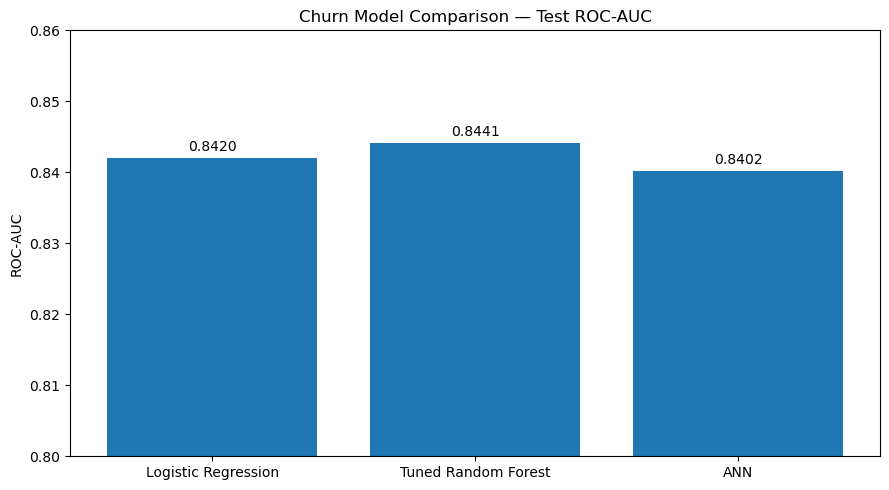

In [363]:
models = [
    "Logistic Regression",
    "Tuned Random Forest",
    "ANN"
]

roc_auc_scores = [
    0.8420,
    0.8441,
    ann_roc_auc
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    models,
    roc_auc_scores
)

plt.ylabel("ROC-AUC")
plt.title("Churn Model Comparison — Test ROC-AUC")
plt.ylim(0.80, 0.86)

for bar, score in zip(bars, roc_auc_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{score:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [365]:
model_comparison_churn.to_csv(
    r"C:\Users\shrey\Documents\Customer_Intelligence_Platform\data\processed\model_comparison.csv",
    index=False
)